In [1]:
# -*- coding: utf-8 -*-
from __future__ import annotations

from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
from workflow import create_model


def pairs_to_complex(values):
    arr = np.asarray(values, dtype=float)
    if arr.ndim == 1:
        return arr.astype(complex)
    return arr[:, 0] + 1j * arr[:, 1]


TASK_DIR = Path("task5")
model = create_model(task_config=TASK_DIR / 'task_x.yaml')
model.run_all()

best control_scale = 1.0
best drag_beta = 0.24736842105263157


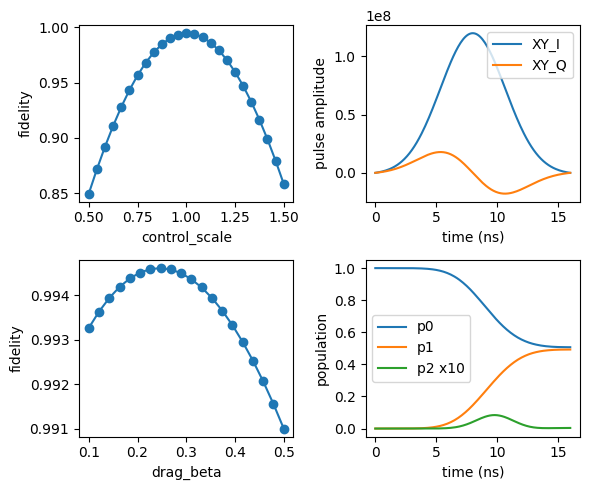

In [2]:
import pandas as pd

model = create_model(
    task_config=TASK_DIR / 'task_sx.yaml',
    pulse_config=TASK_DIR / 'pulse_drag.yaml',
)

rho_target = np.array([
    [0.5, 0.5j, 0.0],
    [-0.5j, 0.5, 0.0],
    [0.0, 0.0, 0.0],
], dtype=complex)

scales = np.linspace(0.5, 1.5, 25)
betas  = np.linspace(0.1, 0.5, 20)

scan_results = []
for s in scales:
    for b in betas:
        model.device.device["control_scale"] = float(s)
        model.pulse['single_qubit_drag_beta'] = float(b)
        model.run_all()
        pops = model.results.analyses["analyser_0"].metrics["population"]["values"]
        t = np.asarray(model.results.analyses["analyser_0"].metrics["population"]["times"]) * 1e9

        rho_end = np.array(model.results.trajectories['solver_0'].density_matrix['snapshots'][-1])
        fid = float(np.real(np.trace(rho_end @ rho_target)))

        scan_results.append({
            "control_scale": model.device.device["control_scale"],
            "drag_beta": model.pulse['single_qubit_drag_beta'],
            "times": t,
            "p0": np.real(pops["0"]),
            "p1": np.real(pops["1"]),
            "p2": np.real(pops["2"]),
            "fidelity": fid,
        })

df = pd.DataFrame(scan_results)

best_idx = int(df["fidelity"].idxmax())
best_scale = float(df.loc[best_idx, "control_scale"])
best_beta = float(df.loc[best_idx, "drag_beta"])
print("best control_scale =", best_scale)
print("best drag_beta =", best_beta)

model.device.device["control_scale"] = best_scale
model.pulse['single_qubit_drag_beta'] = float(df.loc[best_idx, "drag_beta"])
model.run_all()


from musiq.pulse.sequence import PulseCompiler
pulse_ir = model.results.solver_runs["solver_0"].pulse_ir
pulse_samples = PulseCompiler.compile(pulse_ir, sample_rate_Hz=1e10)

t_ns = pulse_samples["XY_0"]["t"] * 1e9
y_i = pulse_samples["XY_0"]["y"]
y_q = pulse_samples["XY_0"]["y_quadrature"]
# z  = pulse_samples["Z_0"]["y"]

f = plt.figure(figsize=(6, 5))

df_scale = df[df["drag_beta"] == best_beta]
ax = f.add_subplot(2, 2, 1)
ax.plot(df_scale["control_scale"], df_scale["fidelity"], marker='o')
ax.set_xlabel("control_scale")
ax.set_ylabel("fidelity")

df_beta = df[df["control_scale"] == best_scale]
ax = f.add_subplot(2, 2, 3)
ax.plot(df_beta["drag_beta"], df_beta["fidelity"], marker='o')
ax.set_xlabel("drag_beta")
ax.set_ylabel("fidelity")

ax = f.add_subplot(2, 2, 2)
ax.plot(t_ns, y_i, label="XY_I")
ax.plot(t_ns, y_q, label="XY_Q")
ax.set_xlabel("time (ns)")
ax.set_ylabel("pulse amplitude")
ax.legend()

ax = f.add_subplot(2, 2, 4)
ax.plot(df["times"].iloc[best_idx], df["p0"].iloc[best_idx], label="p0")
ax.plot(df["times"].iloc[best_idx], df["p1"].iloc[best_idx], label="p1")
ax.plot(df["times"].iloc[best_idx], 10 * df["p2"].iloc[best_idx], label="p2 x10")
ax.set_xlabel("time (ns)")
ax.set_ylabel("population")
ax.legend()

plt.tight_layout()
plt.show()
